# **Aspect Based Sentiment (3 classes) Laptop + Restaurant ABSA Dataset  - Comparison**

### Install Dependencies

In [ ]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets
!pip install -q psutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 58.3 MB/s eta 0:00:00


### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import torch
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback, AutoConfig
)
from peft import LoraConfig, TaskType, get_peft_model

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Load and Explore Data

Total instances: 5914
Number of instances per sentiment:
Sentiment
Positive    3151
Negative    1671
Neutral     1092
Name: count, dtype: int64


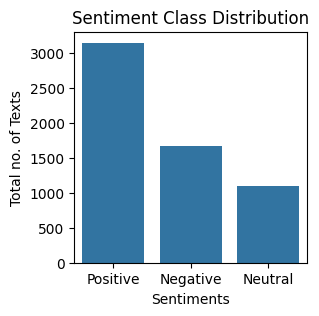

In [ ]:
file_path = "/content/drive/MyDrive/Laptop + Restaurant - ABSA.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')
df = df[['Text', 'Sentiment']].dropna()
df.head()

# file_path = "/home/arafatmdeasin/usman/project/dataset/Laptop + Restaurant - ABSA.csv"
# df = pd.read_csv(file_path, encoding='ISO-8859-1')
# df = df[['Text', 'Sentiment']].dropna()
# df.head()

total_instances = len(df)
print(f"Total instances: {total_instances}")

sentiment_counts = df['Sentiment'].value_counts()
print("Number of instances per sentiment:")
print(sentiment_counts)

plt.figure(figsize=(3,3))
sns.countplot(data=df, x='Sentiment')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiments")
plt.ylabel("Total no. of Texts")
plt.grid(False)
plt.show()

### Preprocessing

In [ ]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Sentiment'])

print("Label Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['Text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"Train size: {len(train_texts)}, Val size: {len(val_texts)}, Test size: {len(test_texts)}")

Label Mapping:
Negative: 0
Neutral: 1
Positive: 2
Train size: 4731, Val size: 591, Test size: 592


### Tokenization

In [ ]:
base_model_name = "microsoft/deberta-v3-base"
finetuned_model_name = "yangheng/deberta-v3-base-absa-v1.1"
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
val_encodings   = tokenizer(val_texts, truncation=True, padding=True, max_length=512)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=512)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


### Dataset Class

In [ ]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()} | {'labels': torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset  = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

### Utility Functions

In [ ]:
def get_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        return torch.cuda.max_memory_allocated() / 1024**3
    return 0

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    proba = torch.softmax(torch.tensor(logits), dim=-1).numpy()

    acc = accuracy_score(labels, preds) * 100
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")

    sims = []
    for i in range(len(labels)):
        true_onehot = np.zeros(proba.shape[1])
        true_onehot[labels[i]] = 1
        sims.append(cosine_similarity([true_onehot], [proba[i]])[0][0])
    similarity_score = np.mean(sims) * 100

    confidence_score = np.mean(np.max(proba, axis=1)) * 100

    return {
        "eval_Accuracy": acc,
        "eval_Precision": prec * 100,
        "eval_Recall": rec * 100,
        "eval_F1 Score": f1 * 100,
        "eval_Similarity Score": similarity_score,
        "eval_Confidence Score": confidence_score
    }


results = {}

### Baseline Models Evaluation

In [ ]:
print("=== BASELINE MODELS EVALUATION ===\n")

# Baseline DeBERTa
print("Evaluating Baseline DeBERTa...")
baseline_model = AutoModelForSequenceClassification.from_pretrained(finetuned_model_name)
baseline_trainer = Trainer(
    model=baseline_model,
    args=TrainingArguments(output_dir="./results", per_device_eval_batch_size=32, report_to="none"),
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
baseline_metrics = baseline_trainer.evaluate()
results['baseline_deberta'] = baseline_metrics

print("\n===== Performance of DeBERTa Model =====\n")
metrics_to_show = ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]
for metric in metrics_to_show:
    key = f"eval_{metric}"
    if key in baseline_metrics:
        print(f"{metric} is: {baseline_metrics[key]:.2f}%")

=== BASELINE MODELS EVALUATION ===

Evaluating Baseline DeBERTa...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]


===== Performance of DeBERTa Model =====

Accuracy is: 75.84%
Precision is: 71.05%
Recall is: 73.23%
F1 Score is: 71.84%
Similarity Score is: 80.38%
Confidence Score is: 78.00%


### Baseline Confusion Matrices


=== BASELINE CONFUSION MATRIX ===


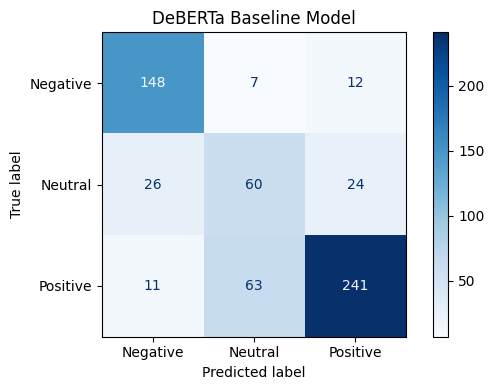

219

In [ ]:
print("\n=== BASELINE CONFUSION MATRIX ===")
preds = baseline_trainer.predict(test_dataset)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)

class_names = label_encoder.classes_

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
ax.set_title("DeBERTa Baseline Model")
plt.tight_layout()
plt.show()

del baseline_model, baseline_trainer
torch.cuda.empty_cache()
gc.collect()

### Fine-tuning BERT

In [ ]:
print("=== FINE-TUNING DeBERTa ===")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

start_time = time.time()

config = AutoConfig.from_pretrained(
    base_model_name,
    num_labels=len(label_encoder.classes_),
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3,
    classifier_dropout=0.2
)

model_base = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    config=config
)

total_params_before = sum(p.numel() for p in model_base.parameters())
trainable_params_before = sum(p.numel() for p in model_base.parameters() if p.requires_grad)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.1,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_strategy="epoch",
    report_to="none",
    fp16=True,
    gradient_accumulation_steps=1,
    save_total_limit=2,
    max_grad_norm=1.0,
    lr_scheduler_type="linear",
    seed=42,
    dataloader_pin_memory=False,
)

trainer_base = Trainer(
    model=model_base,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3),
    ]
)

trainer_base.train()
training_time = time.time() - start_time

gpu_memory = get_gpu_memory()

finetuned_metrics = trainer_base.evaluate(test_dataset)

results['finetuned_deberta'] = {
    **finetuned_metrics,
    'training_time': training_time,
    'total_parameters': total_params_before,
    'trainable_parameters': trainable_params_before,
    'gpu_memory_gb': gpu_memory
}

=== FINE-TUNING DeBERTa ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
1,0.876800,0.631939,74.957699,66.106800,62.844755,61.125152,79.454358,80.287842
2,0.628500,0.654099,76.649746,70.637175,67.058735,67.710118,79.999899,86.723854
3,0.546000,0.641489,79.864636,75.001607,73.344815,73.342529,81.882372,88.874275
4,0.488800,0.664486,79.187817,73.923517,73.721495,73.377238,81.085231,90.210876


### Fine-tuned Confusion Matrices


=== FINE-TUNED CONFUSION MATRIX ===


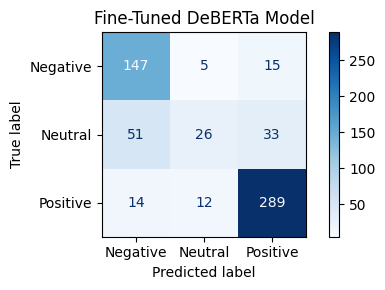

In [ ]:
print("\n=== FINE-TUNED CONFUSION MATRIX ===")
preds = trainer_base.predict(test_dataset)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
ax.set_title("Fine-Tuned DeBERTa Model")
plt.tight_layout()
plt.show()

### Fine-tuned Training & Validation Loss

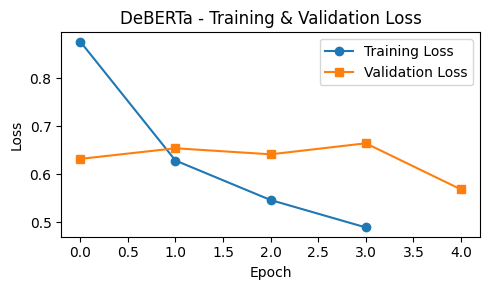

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

train_loss = [log['loss'] for log in trainer_base.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss = [log['eval_loss'] for log in trainer_base.state.log_history if 'eval_loss' in log]

ax.plot(train_loss, label='Training Loss', marker="o")
ax.plot(eval_loss, label='Validation Loss', marker="s")
ax.set_title('DeBERTa - Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
import gc, torch

for var_name in ["model_base", "trainer_base"]:
    if var_name in globals():
        del globals()[var_name]

torch.cuda.empty_cache()
gc.collect()


14126

### Adapter (LoRA) BERT

In [ ]:
print("=== ADAPTER (LoRA) DeBERTa OPTIMIZED ===")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

start_time = time.time()

adapter_model = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=len(label_encoder.classes_)
)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query_proj", "value_proj", "output.dense"],
    bias="none",
    modules_to_save=["classifier"]
)

adapter_model = get_peft_model(adapter_model, peft_config)
adapter_model.print_trainable_parameters()

adapter_args = TrainingArguments(
    output_dir="./results-adapter-optimized",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=6,
    weight_decay=0.01,
    warmup_ratio=0.05,
    logging_dir="./logs-adapter",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=42,
    fp16=True,
    gradient_accumulation_steps=1,
    max_grad_norm=1.0,
    logging_steps=50,
    save_total_limit=2,
    lr_scheduler_type="cosine",
    dataloader_pin_memory=False,
    remove_unused_columns=True
)

trainer_adapter = Trainer(
    model=adapter_model,
    args=adapter_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
    ]
)

trainer_adapter.train()
training_time_lora = time.time() - start_time

gpu_memory_lora = get_gpu_memory()

adapter_metrics = trainer_adapter.evaluate(test_dataset)

results['adapter_deberta'] = {
    **adapter_metrics,
    'training_time': training_time_lora,
    'total_parameters': sum(p.numel() for p in adapter_model.parameters()),
    'trainable_parameters': sum(p.numel() for p in adapter_model.parameters() if p.requires_grad),
    'gpu_memory_gb': gpu_memory_lora
}

=== ADAPTER (LoRA) DeBERTa OPTIMIZED ===


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


trainable params: 813,315 || all params: 185,237,766 || trainable%: 0.4391


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
1,0.770500,0.635762,71.065990,62.080296,63.048053,62.422511,78.405434,74.181816
2,0.565100,0.627416,74.957699,67.166925,66.075108,66.523100,79.830193,81.762001
3,0.492100,0.607046,76.480541,71.458680,65.740545,66.281696,80.509373,86.801277
4,0.424500,0.568820,77.834179,71.831416,70.006148,70.056455,81.785490,86.538780
5,0.381700,0.609438,77.664975,72.323972,69.424646,70.477242,80.672399,88.129929
6,0.354200,0.584403,77.157360,71.058353,69.951212,70.356497,80.946989,87.359818


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in ver

In [ ]:
print(f"Predictions: {np.unique(y_pred)}")


Predictions: [0 1 2]


### Adapter Confusion Matrices


=== ADAPTER CONFUSION MATRIX ===


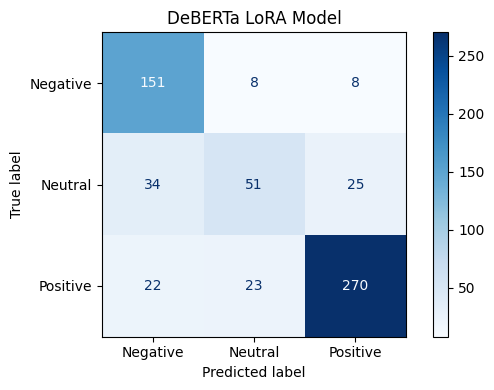

In [ ]:
print("\n=== ADAPTER CONFUSION MATRIX ===")
preds = trainer_adapter.predict(test_dataset)
y_true, y_pred = preds.label_ids, preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
ax.set_title("DeBERTa LoRA Model")
plt.tight_layout()
plt.show()

### Adapter Training & Validation Loss

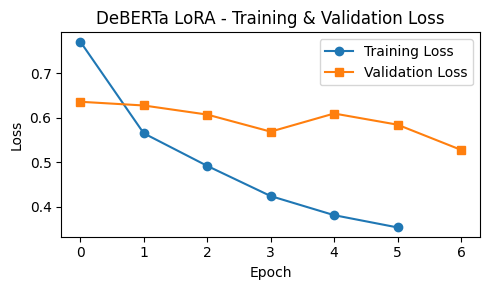

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

train_loss = [log['loss'] for log in trainer_adapter.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss = [log['eval_loss'] for log in trainer_adapter.state.log_history if 'eval_loss' in log]

ax.plot(train_loss, label='Training Loss', marker="o")
ax.plot(eval_loss, label='Validation Loss', marker="s")
ax.set_title('DeBERTa LoRA - Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

### Comprehensive Comparison Table

In [ ]:
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

comparison_data = []

models = [
    ('Baseline DeBERTa', 'baseline_deberta'),
    ('Fine-Tuned DeBERTa', 'finetuned_deberta'),
    ('Adapter DeBERTa', 'adapter_deberta')
]

for model_name, model_key in models:
    if model_key in results:
        metrics = results[model_key]
        row = {
            'Model': model_name,
            'Accuracy': metrics.get('eval_Accuracy', 0),
            'Precision': metrics.get('eval_Precision', 0),
            'Recall': metrics.get('eval_Recall', 0),
            'F1 Score': metrics.get('eval_F1 Score', 0),
            'Similarity': metrics.get('eval_Similarity Score', 0),
            'Confidence': metrics.get('eval_Confidence Score', 0),
            'Training Time (s)': metrics.get('training_time', 'N/A'),
            'Trainable Params': metrics.get('trainable_parameters', 'N/A'),
            'GPU Memory (GB)': metrics.get('gpu_memory_gb', 'N/A')
        }
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

numeric_columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Similarity', 'Confidence']
for col in numeric_columns:
    comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)

print("\nCOMPREHENSIVE COMPARISON TABLE:")
print(comparison_df.to_string(index=False))


COMPREHENSIVE MODEL COMPARISON

COMPREHENSIVE COMPARISON TABLE:
             Model Accuracy Precision Recall F1 Score Similarity Confidence Training Time (s) Trainable Params GPU Memory (GB)
  Baseline DeBERTa    75.84     71.05  73.23    71.84      80.38      78.00               N/A              N/A             N/A
Fine-Tuned DeBERTa    78.04     71.85  67.80    66.74      81.80      80.09        479.055777        184424451        3.469903
   Adapter DeBERTa    79.73     74.75  74.17    73.75      83.25      85.77        251.133042           813315        2.453668


### Performance Visualization

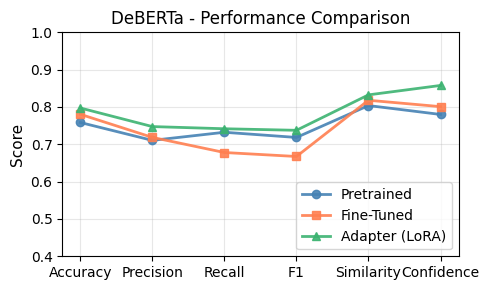

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "Similarity", "Confidence"]

# DeBERTa metrics
pretrained_vals = np.array([baseline_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
base_vals = np.array([finetuned_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
adapter_vals = np.array([adapter_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100

x = np.arange(len(metrics))

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

ax.plot(x, pretrained_vals, marker='o', linestyle='-', linewidth=2, alpha=0.9, label="Pretrained", color='steelblue')
ax.plot(x, base_vals, marker='s', linestyle='-', linewidth=2, alpha=0.9, label="Fine-Tuned", color='coral')
ax.plot(x, adapter_vals, marker='^', linestyle='-', linewidth=2, alpha=0.9, label="Adapter (LoRA)", color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0.40, 1.00)
ax.set_title("DeBERTa - Performance Comparison", fontsize=12,)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

### Resource Usage Comparison

In [ ]:
# Extract data
deberta_ft = results['finetuned_deberta']
deberta_ad = results['adapter_deberta']

# DeBERTa Table
print("\n" + "DeBERTa - RESOURCE USAGE".center(40))
print("-" * 40)
print(f"{'Metric':<20} {'Fine-Tuned':<12} {'Adapter':<12}")
print("-" * 40)
print(f"{'Training Time (s)':<20} {deberta_ft['training_time']:<12.0f} {deberta_ad['training_time']:<12.0f}")
print(f"{'Trainable Params':<20} {deberta_ft['trainable_parameters']:<12,} {deberta_ad['trainable_parameters']:<12,}")
print(f"{'GPU Memory (GB)':<20} {deberta_ft['gpu_memory_gb']:<12.2f} {deberta_ad['gpu_memory_gb']:<12.2f}")
print("-" * 40)


        DeBERTa - RESOURCE USAGE        
----------------------------------------
Metric               Fine-Tuned   Adapter     
----------------------------------------
Training Time (s)    479          251         
Trainable Params     184,424,451  813,315     
GPU Memory (GB)      3.47         2.45        
----------------------------------------
